In [15]:
import logging
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits import mplot3d
from IPython.display import HTML, Image
from sklearn import svm
from sklearn.datasets import make_circles

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

#https://xavierbourretsicotte.github.io/Kernel_feature_map.html

In [16]:
def feature_map_0(X):
  return X

def feature_map_1(X):
    return np.asarray((X[:,0], X[:,1], X[:,0]**2 + X[:,1]**2)).T

def feature_map_2(X):  
    return np.asarray((X[:,0], X[:,1], np.exp( -( X[:,0]**2 + X[:,1]**2)))).T

def feature_map_3(X):  
    return np.asarray(( np.sqrt(2) *X[:,0] * X[:,1], X[:,0]**2, X[:,1]**2)).T

def kernel_0(X,Y):
  return X@Y.T

def kernel_1(X,Y):
  Z1 = feature_map_1(X)
  Z2 = feature_map_1(Y)
  return Z1@Z2.T

def kernel_2(X,Y):
  Z1 = feature_map_2(X)
  Z2 = feature_map_2(Y)
  return Z1@Z2.T

def kernel_3(X,Y):
  Z1 = feature_map_3(X)
  Z2 = feature_map_3(Y)
  return Z1@Z2.T

In [17]:
#Generate dataset and feature-map
X, y = make_circles(100, factor=.1, noise=.1)
Z1 = feature_map_1(X)
Z2 = feature_map_2(X)
Z3 = feature_map_3(X)

with plt.xkcd():

  #2D scatter plot
  fig = plt.figure(figsize = (16,8))
  ax = fig.add_subplot(2, 2, 1)
  ax.scatter(X[:,0], X[:,1], c = y, cmap = 'viridis')
  ax.set_xlabel('$x_1$')
  ax.set_ylabel('$x_2$')
  ax.set_title('Original dataset')

  #3D scatter plot
  ax = fig.add_subplot(2, 2, 2, projection='3d')
  ax.scatter3D(Z1[:,0],Z1[:,1], Z1[:,2],c = y, cmap = 'viridis' ) #,rstride = 5, cstride = 5, cmap = 'jet', alpha = .4, edgecolor = 'none' )
  ax.set_xlabel('$z_1$')
  ax.set_ylabel('$z_2$')
  ax.set_zlabel('$z_3$')
  ax.set_title('Transformed dataset')

  ax = fig.add_subplot(2, 2, 3, projection='3d')
  ax.scatter3D(Z2[:,0],Z2[:,1], Z2[:,2],c = y, cmap = 'viridis' ) #,rstride = 5, cstride = 5, cmap = 'jet', alpha = .4, edgecolor = 'none' )
  ax.set_xlabel('$z_1$')
  ax.set_ylabel('$z_2$')
  ax.set_zlabel('$z_3$')
  ax.set_title('Transformed dataset')

  ax = fig.add_subplot(2, 2, 4, projection='3d')
  ax.scatter3D(Z3[:,0],Z3[:,1], Z3[:,2],c = y, cmap = 'viridis' ) #,rstride = 5, cstride = 5, cmap = 'jet', alpha = .4, edgecolor = 'none' )
  ax.set_xlabel('$z_1$')
  ax.set_ylabel('$z_2$')
  ax.set_zlabel('$z_3$')
  ax.set_title('Transformed dataset')

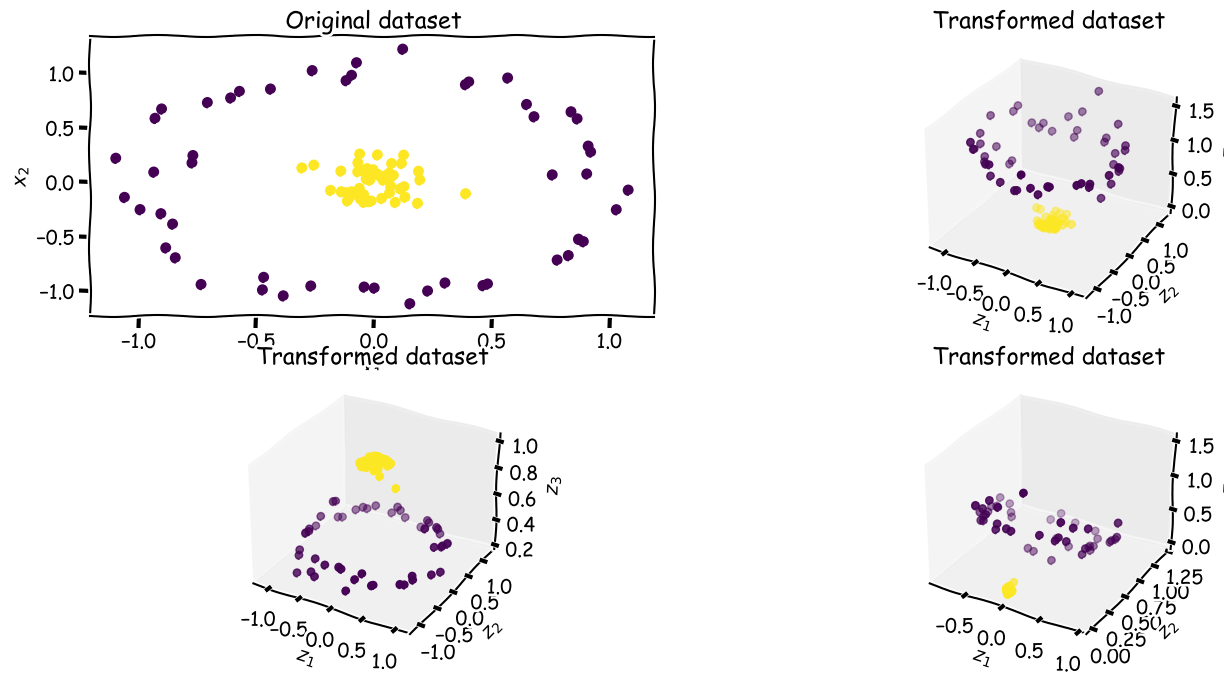

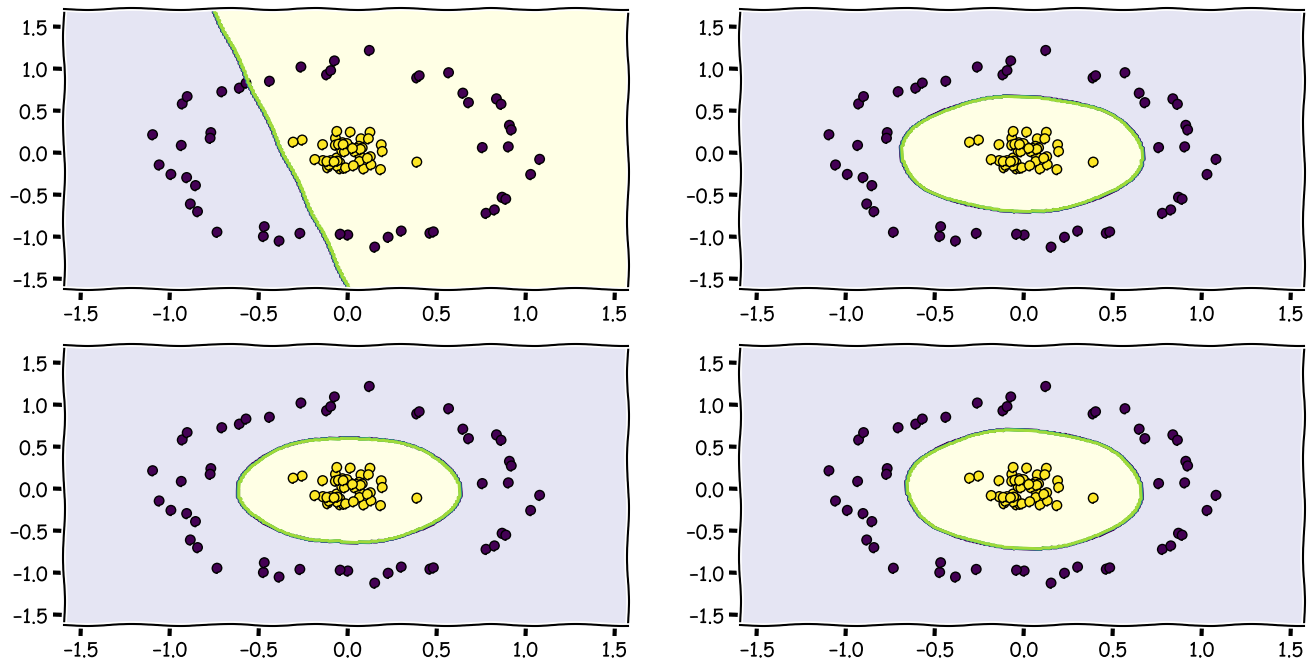

In [18]:
clf0 = svm.SVC(kernel=kernel_0)
clf1 =  svm.SVC(kernel=kernel_1)
clf2 =  svm.SVC(kernel=kernel_2)
clf3 = svm.SVC(kernel=kernel_3)
# kernel computation
clf0.fit(X, y)
clf1.fit(X,y)
clf2.fit(X,y)
clf3.fit(X,y) 

#Initialize data
h = .01 #Stepsize in the mesh
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

#Predict on meshgrid
Z0 = clf0.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z1 = clf1.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z2 = clf2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z3 = clf3.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Put the result into a color plot
with plt.xkcd():
  fig = plt.figure(figsize = (16,8))
  ax = fig.add_subplot(2,2,1)
  ax.contourf(xx, yy, Z0,1, colors = ['darkblue','yellow'], alpha = .1)
  ax.contour(xx, yy, Z0, cmap = 'viridis')
# Plot also the training points
  ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors = 'k')

  ax = fig.add_subplot(2,2,2)
  ax.contourf(xx, yy, Z1,1, colors = ['darkblue','yellow'], alpha = .1)
  ax.contour(xx, yy, Z1, cmap = 'viridis')
# Plot also the training points
  ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors = 'k')

  ax = fig.add_subplot(2,2,3)
  ax.contourf(xx, yy, Z2,1, colors = ['darkblue','yellow'], alpha = .1)
  ax.contour(xx, yy, Z2, cmap = 'viridis')
# Plot also the training points
  ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors = 'k')

  ax = fig.add_subplot(2,2,4)
  ax.contourf(xx, yy, Z3,1, colors = ['darkblue','yellow'], alpha = .1)
  ax.contour(xx, yy, Z3, cmap = 'viridis')
# Plot also the training points
  ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors = 'k')

plt.show()